In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels
import shap
sns.set_theme(style="whitegrid", palette="muted")


In [2]:
print(os.getcwd())

D:\R Working Directory\Used Car Analyser\src\used_car_analyser


In [4]:
os.chdir("..")

In [5]:
df = pd.read_csv("data/carmax_usa_enriched.csv")

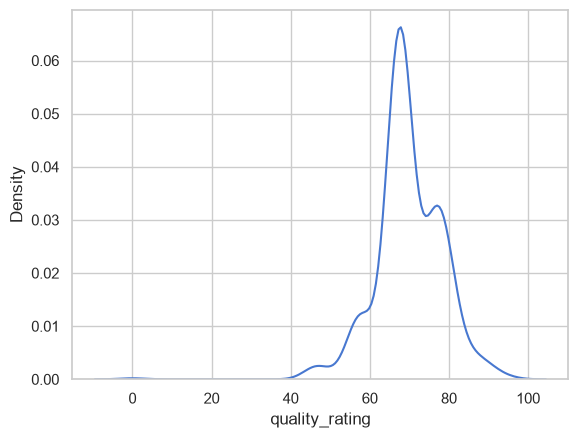

In [7]:
g1 = sns.kdeplot(
    data=df,
    x='quality_rating',
    bw_adjust=2
)
plt.show()



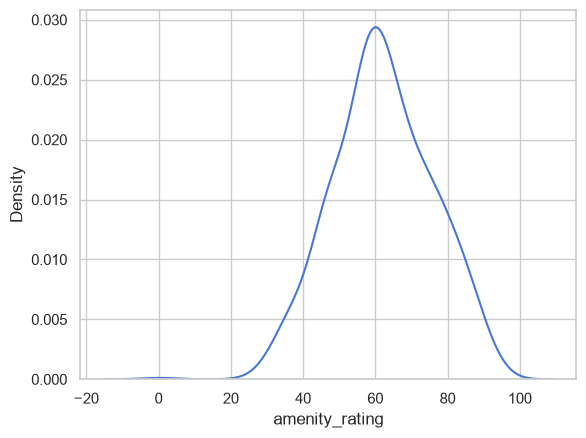

In [8]:
g1 = sns.kdeplot(
    data=df,
    x='amenity_rating',
    bw_adjust=2
)
plt.show()


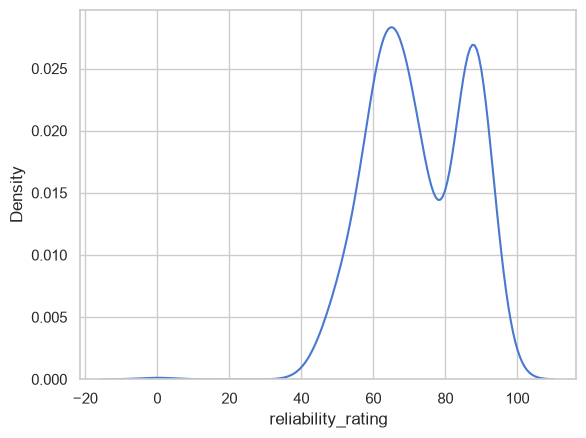

In [9]:
g1 = sns.kdeplot(
    data=df,
    x='reliability_rating',
    bw_adjust=2
)
plt.show()


In [8]:
df = df[df['quality_rating']>0]
df['log_price'] = np.log(df['price'])

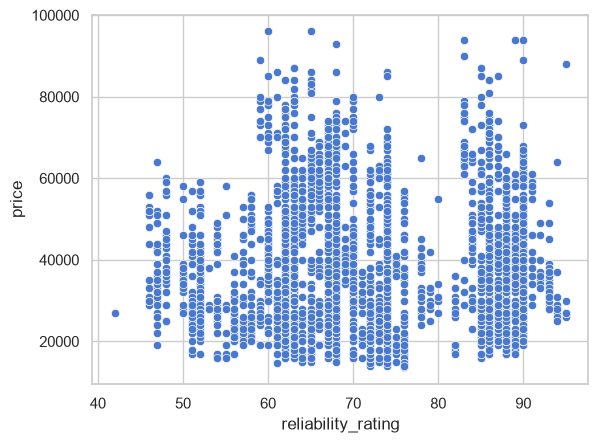

In [11]:
g1 = sns.scatterplot(
    data=df,
    x='reliability_rating',
    y='price'
)
plt.show()

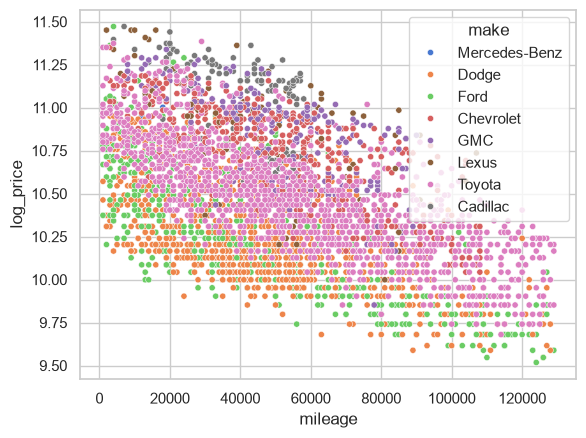

In [30]:
g1 = sns.scatterplot(
    data=df,
    x='mileage',
    y='price',
    hue="make",
    s=20
)

#g1 = sns.set_yscale('log')

plt.show()

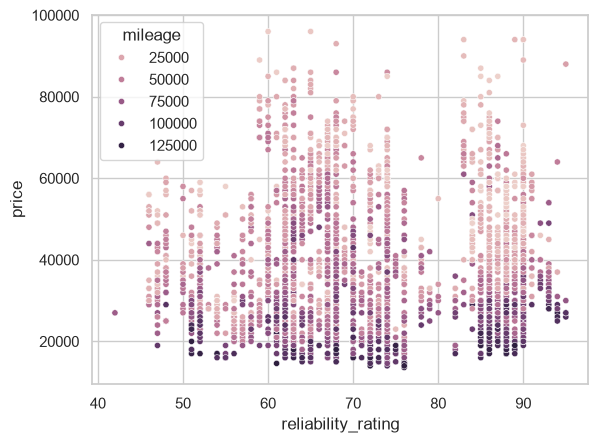

In [13]:
g1 = sns.scatterplot(
    data=df,
    x='reliability_rating',
    y='price',
    hue="mileage",
    s=20
)

#g1 = sns.set_yscale('log')

plt.show()

In [32]:
v8_muscle = df[
        (
            ((df['make'] == 'Dodge') & (df['model'] == 'Challenger') & (df['cylinders'] == 8)) |
            ((df['make'] == 'Ford') & (df['model'] == 'Mustang') & (df['cylinders'] == 8))
        ) & 
        #(~df['model'].str.contains('Shelby', case=False, na=False))&
        (df['horsepower']>400)&
        (df['horsepower']<500)&
        (df['mileage']>0)
    ].copy()

D:\R Working Directory\Used Car Analyser\.venv\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


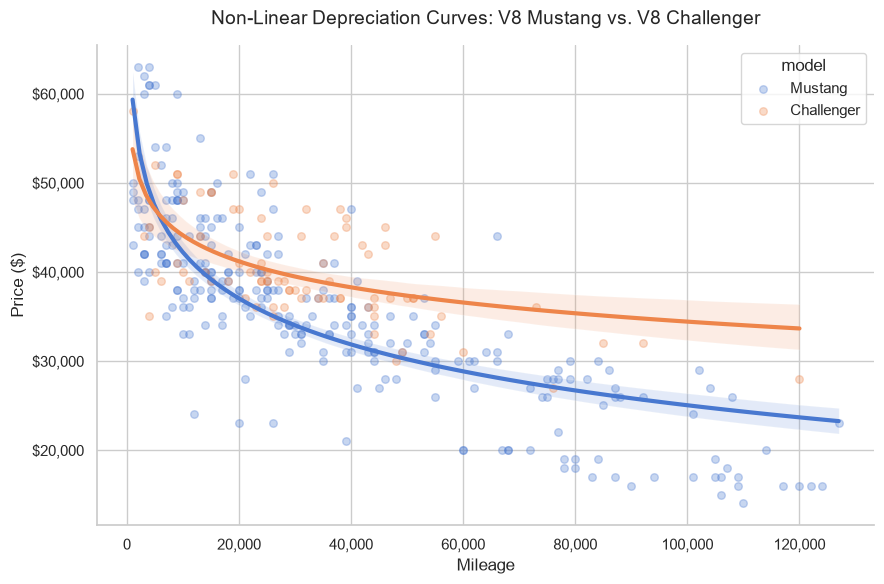

In [34]:
g1 = sns.lmplot(
        data=v8_muscle, 
        x='mileage', 
        y='price', 
        hue='model',
        #lowess=True, 
        logx=True,
        scatter_kws={'alpha': 0.3, 's': 30}, # Make points semi-transparent and smaller
        line_kws={'linewidth': 3},           # Make the line of best fit pop
        height=6, 
        aspect=1.5,
        legend_out=False
    )
g1.set_axis_labels('Mileage', 'Price ($)')
plt.title('Non-Linear Depreciation Curves: V8 Mustang vs. V8 Challenger', pad=15, fontsize=14)
# Format axes with commas
g1.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
g1.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${format(int(y), ',')}"))
plt.tight_layout()
plt.show()

In [ ]:

g1 = sns.lmplot(
        data=v8_muscle, 
        x='mileage', 
        y='price', 
        hue='model',
        #lowess=True, 
        logx=True,
        scatter_kws={'alpha': 0.3, 's': 30}, # Make points semi-transparent and smaller
        line_kws={'linewidth': 3},           # Make the line of best fit pop
        height=6, 
        aspect=1.5,
        legend_out=False
    )
g1.set_axis_labels('Mileage', 'Price ($)')
plt.title('Non-Linear Depreciation Curves: V8 Mustang vs. V8 Challenger', pad=15, fontsize=14)
# Format axes with commas
g1.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
g1.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${format(int(y), ',')}"))
plt.tight_layout()
plt.show()

In [38]:
perf_cars = df[(df['accel']<4.5) & (df['fuel_economy']>0)]

perf_cars_agg = perf_cars.groupby('make_model').agg(
    n=('make_model','size'),
    price = ('price','median'),
    mileage = ('mileage','median'),
    qmile = ('qmile_time','mean'),
    quality = ('quality_rating','mean'),
    amenity = ('amenity_rating','mean'),
    reliability = ('reliability_rating','mean'),
    economy = ('fuel_economy','mean')
).reset_index()

print(perf_cars_agg.sort_values(by='qmile'))

              make_model    n    price  mileage      qmile    quality  \
8  Mercedes-Benz C63 AMG   13  54998.0  29000.0  12.053846  87.615385   
0       Dodge Challenger   82  38998.0  28500.0  12.331707  63.195122   
1          Dodge Charger   97  43998.0  26000.0  12.403093  66.360825   
4           Lexus IS 500    9  60998.0  25000.0  12.422222  86.555556   
3           Ford Mustang  280  37498.0  25000.0  12.475000  68.335714   
7             Lexus RC F    4  40998.0  70500.0  12.600000  85.750000   
2          Dodge Durango    7  48998.0  46000.0  12.685714  67.000000   
5           Lexus LC 500    9  80998.0  14000.0  12.800000  90.000000   
6           Lexus LS 500   11  41998.0  48000.0  12.800000  92.909091   

     amenity  reliability    economy  
8  83.923077    49.076923  18.615385  
0  51.036585    56.414634  13.231707  
1  57.144330    58.103093  13.896907  
4  80.666667    87.555556  18.000000  
3  62.960714    68.760714  14.939286  
7  75.750000    83.750000  16.00000

In [14]:
df_agg = df.groupby('make_model').agg(
    quality = ('quality_rating','mean'),
    amenity = ('amenity_rating','mean'),
    reliability = ('reliability_rating','mean'),
    economy = ('fuel_economy','mean'),
    n=('make_model','size'),
    mileage = ('mileage','median'),
    price = ('price','median')
    
).reset_index()

print(df_agg.sort_values(by=['reliability','quality'], ascending=[False,False]).head(n=10))


                 make_model    quality    amenity  reliability    economy  \
20      Toyota Land Cruiser  80.920000  66.840000    89.560000  15.200000   
17           Toyota 4Runner  67.159696  48.513308    89.228137  16.245247   
10             Lexus LC 500  90.000000  84.555556    87.666667  16.000000   
9              Lexus IS 500  86.555556  80.666667    87.555556  18.000000   
19        Toyota Highlander  76.296243  67.372832    87.426301  23.420520   
13             Lexus LX 570  85.235294  70.705882    86.882353  13.235294   
12             Lexus LS 500  93.000000  90.700000    86.250000  18.450000   
18  Toyota Grand Highlander  78.240741  73.259259    85.703704  24.037037   
21           Toyota Sequoia  74.230769  65.769231    85.320513  16.435897   
15               Lexus RC F  85.750000  75.750000    83.750000  16.000000   

      n  mileage    price  
20   25   9000.0  60998.0  
17  526  58000.0  37998.0  
10    9  14000.0  80998.0  
9     9  25000.0  60998.0  
19  692  540

In [15]:
print(df_agg[df_agg['price']<35000].sort_values(by=['reliability','quality'], ascending=[False,False]).head(n=10))

           make_model    quality    amenity  reliability    economy    n  \
19  Toyota Highlander  76.296243  67.372832    87.426301  23.420520  692   
11       Lexus LS 460  89.040000  83.880000    77.360000  17.280000   25   
6        Ford Mustang  68.145215  62.184818    68.764026  19.468647  606   
4       Dodge Charger  64.355641  58.022945    61.242830  17.713193  523   
3    Dodge Challenger  60.551913  48.751366    60.551913  16.956284  366   
5       Dodge Durango  66.586420  65.370370    59.191358  16.592593  162   

    mileage    price  
19  54000.0  30998.0  
11  69000.0  28998.0  
6   39000.0  26998.0  
4   45000.0  25998.0  
3   42000.0  26998.0  
5   44000.0  31998.0  


In [7]:
x_vars = ['mileage']
x = df[x_vars]
x = sm.add_constant(x)
y = df['log_price']
lm = sm.OLS(y,x).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     1830.
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        01:41:51   Log-Likelihood:                -977.87
No. Observations:                3967   AIC:                             1960.
Df Residuals:                    3965   BIC:                             1972.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.8119      0.010   1115.740      0.0

In [8]:
params = lm.params
print("Percent change for each point of independent variables:\n")
transformed_coef = 100*(np.exp(params)-1)
for var,val in transformed_coef.items():
    if var=='const':
        continue
    print(f"{var}: {val:4f}%")

Percent change for each point of independent variables:

mileage: -0.000708%


In [11]:
beta_mileage = lm.params['mileage']
prop_change = 100*(np.exp(beta_mileage*50000)-1)
print("Impact of 50,000 mile increase")
print(f"{prop_change}%")

Impact of 50,000 mile increase
-29.80210476834647%


In [13]:
def pareto_filter(df, maximize_cols, minimize_cols):
    """
    Remove dominated rows from a DataFrame.
    """
    # 1. Select only the columns we care about
    compare_cols = maximize_cols + minimize_cols
    
    # 2. Drop rows with NaN in any of the comparison columns
    df_clean = df[compare_cols].dropna()
    
    if df_clean.empty:
        return df.iloc[:0]

    # 3. Normalize each column to [0, 1]
    normalized = pd.DataFrame(index=df_clean.index)
    
    for col in maximize_cols:
        col_min = df_clean[col].min()
        col_max = df_clean[col].max()
        if col_max == col_min:
            normalized[col] = 0.5 
        else:
            normalized[col] = (df_clean[col] - col_min) / (col_max - col_min)
            
    for col in minimize_cols:
        col_min = df_clean[col].min()
        col_max = df_clean[col].max()
        if col_max == col_min:
            normalized[col] = 0.5
        else:
            # Invert: min value becomes 1, max value becomes 0
            normalized[col] = 1 - (df_clean[col] - col_min) / (col_max - col_min)
            
    # 4. Vectorized dominance check
    vals = normalized.values # Shape (N, K)
    n = len(vals)
    
    # Reshape for broadcasting: (N, 1, K) vs (1, N, K)
    # a_dominates_b[i, j] = True if row i dominates row j
    # Check if row i is >= row j on all cols
    ge = vals[:, np.newaxis, :] >= vals[np.newaxis, :, :]
    # Check if row i is > row j on at least one col
    gt = vals[:, np.newaxis, :] > vals[np.newaxis, :, :]
    
    # Dominance: ge is True for all cols AND gt is True for at least one col
    dominates = ge.all(axis=2) & gt.any(axis=2)
    
    # If any row dominates row j, mark j as dominated
    dominated = dominates.any(axis=0)
    
    # Return the NON-dominated rows from the ORIGINAL df
    # We need to map back to the original df index
    return df.loc[df_clean.index[~dominated]].copy()

In [20]:
# Define maximize/minimize columns
df_subset = df[df['mileage']<=70000]
max_cols_df = ['reliability_rating']
min_cols_df = ['price', 'mileage']

# Apply Pareto filter
df_pareto = pareto_filter(df_subset, max_cols_df, min_cols_df)

print(f"=== PROBLEM 1: Pareto Frontier ===")
print("Finding the highest quality, most equipped, most reliable cars for the lowest price with the lowest miles")
print(f"Original listings: {len(df)}")
print(f"Non-dominated listings: {len(df_pareto)}")
print(f"Removed {len(df) - len(df_pareto)} dominated listings")

# Sort by price to see cheapest first
df_pareto = df_pareto.sort_values('price')
print(df_pareto[['make', 'model', 'trim', 'year', 'price', 'mileage', 
                 'reliability_rating', 'quality_rating', 'amenity_rating']].head(20))

=== PROBLEM 1: Pareto Frontier ===
Finding the highest quality, most equipped, most reliable car for the lowest price with the lowest miles
Original listings: 3967
Non-dominated listings: 61
Removed 3906 dominated listings
        make       model      trim  year  price  mileage  reliability_rating  \
45     Dodge     Charger        SE  2014  15998    63000                  74   
52      Ford     Mustang         -  2014  16998    56000                  76   
38     Dodge  Challenger       SXT  2014  17998    52000                  72   
48      Ford     Mustang         -  2014  18998    51000                  76   
517    Dodge     Charger       SXT  2019  18998    50000                  63   
103    Dodge     Charger        SE  2015  18998    42000                  62   
1690  Toyota  Highlander         -  2013  18998    69000                  82   
14     Dodge  Challenger  SXT Plus  2013  19998    24000                  68   
1951  Toyota  Highlander        LE  2016  20998    70000 

In [21]:
pareto_combos = df_pareto[['make', 'model']].drop_duplicates().sort_values(['make', 'model'])

print("=== Unique Makes and Models in Problem 1 Pareto Frontier ===")
print(f"Total unique combinations: {len(pareto_combos)}")
print(pareto_combos.to_string(index=False))

=== Unique Makes and Models in Problem 1 Pareto Frontier ===
Total unique combinations: 7
  make            model
 Dodge       Challenger
 Dodge          Charger
  Ford          Mustang
Toyota          4Runner
Toyota Grand Highlander
Toyota       Highlander
Toyota     Land Cruiser
